In [4]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

file_path = 'diabetes_prediction_dataset.csv'
df = pd.read_csv(file_path)

display(df.head())

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


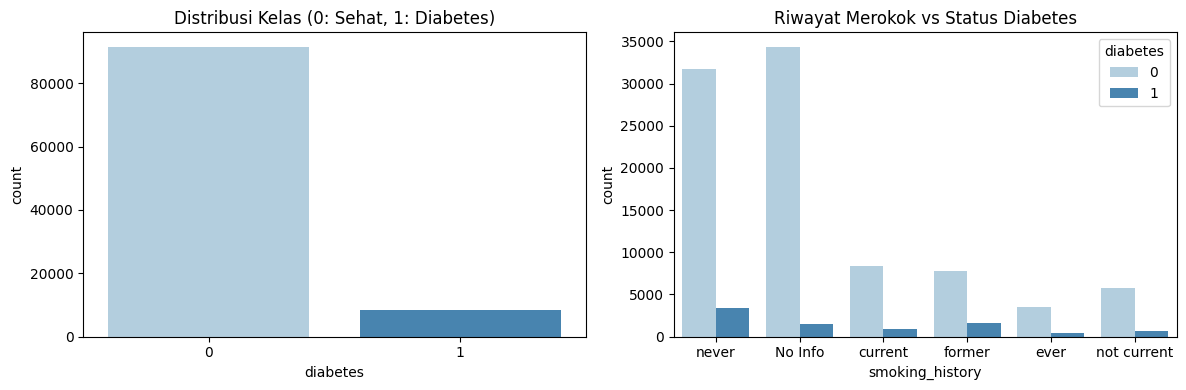

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grafik 1: Bar Chart Distribusi Kelas
sns.countplot(data=df, x='diabetes', ax=axes[0], palette='Blues')
axes[0].set_title('Distribusi Kelas (0: Sehat, 1: Diabetes)')

# Grafik 2: Bar Chart Riwayat Merokok
sns.countplot(data=df, x='smoking_history', hue='diabetes', ax=axes[1], palette='Blues')
axes[1].set_title('Riwayat Merokok vs Status Diabetes')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encoding data teks menjadi angka
le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])

le_smoking = LabelEncoder()
df['smoking_history_encoded'] = le_smoking.fit_transform(df['smoking_history'])

# Membuang kolom teks yang lama
df_clean = df.drop(['gender', 'smoking_history'], axis=1)

print("✅ Data berhasil diubah menjadi angka!")
display(df_clean.head())

✅ Data berhasil diubah menjadi angka!


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_encoded,smoking_history_encoded
0,80.0,0,1,25.19,6.6,140,0,0,4
1,54.0,0,0,27.32,6.6,80,0,0,0
2,28.0,0,0,27.32,5.7,158,0,1,4
3,36.0,0,0,23.45,5.0,155,0,0,1
4,76.0,1,1,20.14,4.8,155,0,1,1


✅ Model berhasil dilatih dengan ukuran yang dioptimalkan!
📊 Tingkat Akurasi Prediksi: 97.21%



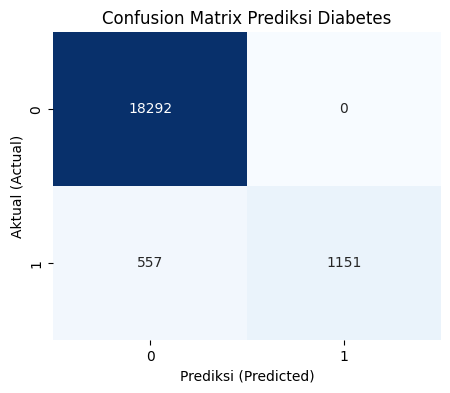

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

X = df_clean.drop('diabetes', axis=1)
y = df_clean['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# PERUBAHAN DISINI: Membatasi n_estimators dan menambah max_depth
# agar ukuran file .pkl menjadi sangat kecil (hanya sekitar 1-2 MB saja)
model_rf = RandomForestClassifier(n_estimators=30, max_depth=8, random_state=42)
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)

akurasi = accuracy_score(y_test, y_pred)
print(f"✅ Model berhasil dilatih dengan ukuran yang dioptimalkan!")
print(f"📊 Tingkat Akurasi Prediksi: {akurasi * 100:.2f}%\n")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix Prediksi Diabetes')
plt.xlabel('Prediksi (Predicted)')
plt.ylabel('Aktual (Actual)')
plt.show()

In [14]:
import pickle

# Menyimpan Model dan Encoder
with open('model_diabetes.pkl', 'wb') as file:
    pickle.dump(model_rf, file)

with open('encoder_diabetes.pkl', 'wb') as file:
    pickle.dump({'gender': le_gender, 'smoking': le_smoking}, file)

print("✅ File 'model_diabetes.pkl' dan 'encoder_diabetes.pkl' berhasil dibuat!")

✅ File 'model_diabetes.pkl' dan 'encoder_diabetes.pkl' berhasil dibuat!


In [11]:
print("Memasukkan data rekam medis pasien baru...\n")

pasien_gender = 'Female'
pasien_age = 50.0
pasien_hypertension = 1
pasien_heart_disease = 0
pasien_smoking = 'former'
pasien_bmi = 28.5
pasien_hba1c = 6.5
pasien_glucose = 140

gender_angka = le_gender.transform([pasien_gender])[0]
smoking_angka = le_smoking.transform([pasien_smoking])[0]

data_pasien_baru = pd.DataFrame([[
    pasien_age, pasien_hypertension, pasien_heart_disease, pasien_bmi,
    pasien_hba1c, pasien_glucose, gender_angka, smoking_angka
]], columns=X.columns)

display(data_pasien_baru)

hasil_prediksi = model_rf.predict(data_pasien_baru)[0]

print("\n" + "="*30)
if hasil_prediksi == 1:
    print("🚨 KESIMPULAN: PASIEN BERISIKO DIABETES!")
else:
    print("✅ KESIMPULAN: PASIEN SEHAT (Risiko Rendah)!")
print("="*30)

Memasukkan data rekam medis pasien baru...



,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_encoded,smoking_history_encoded
0,50.0,1,0,28.5,6.5,140,0,3



✅ KESIMPULAN: PASIEN SEHAT (Risiko Rendah)!
